# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


### Leer conjunto de datos y primer vistazo

In [2]:
df = pd.read_csv('data/mushrooms.csv')
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [3]:
df.describe(include='all')


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

#### Calcular el número de nulos de cada feature

In [5]:
df.isnull().sum()


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [6]:
n_values = df.nunique()
df_unique = pd.DataFrame({'feature': n_values.index, 'n_values': n_values.values}).sort_values('n_values').reset_index(drop=True)
print(df_unique)

# Look for columns containing '?' (a disguised missing value)
cols_with_question_mark = [col for col in df.columns if '?' in df[col].unique()]
print('\nColumns containing "?":', cols_with_question_mark)


                     feature  n_values
0                  veil-type         1
1                      class         2
2            gill-attachment         2
3               gill-spacing         2
4                stalk-shape         2
5                  gill-size         2
6                    bruises         2
7                ring-number         3
8   stalk-surface-above-ring         4
9                 veil-color         4
10               cap-surface         4
11  stalk-surface-below-ring         4
12                 ring-type         5
13                stalk-root         5
14                 cap-shape         6
15                population         6
16                   habitat         7
17                      odor         9
18    stalk-color-above-ring         9
19    stalk-color-below-ring         9
20         spore-print-color         9
21                 cap-color        10
22                gill-color        12

Columns containing "?": ['stalk-root']


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [7]:
mode_stalk_root = df.loc[df['stalk-root'] != '?', 'stalk-root'].mode()[0]
df['stalk-root'] = df['stalk-root'].replace('?', mode_stalk_root)

print('Mode used to impute stalk-root:', mode_stalk_root)
print('Unique values after imputation:', df['stalk-root'].unique())


Mode used to impute stalk-root: b
Unique values after imputation: <StringArray>
['e', 'c', 'b', 'r']
Length: 4, dtype: str


#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [8]:
df = df.drop(columns=['veil-type'])
print('Remaining columns:', df.shape[1])


Remaining columns: 22


#### Separar entre variables predictoras y variable a predecir

In [9]:
y = df['class']
X = df.drop(columns=['class'])


#### Codificar correctamente las variables categóricas a numéricas

In [10]:
X = pd.get_dummies(X)
X.head()


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


#### Train / test split

In [11]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

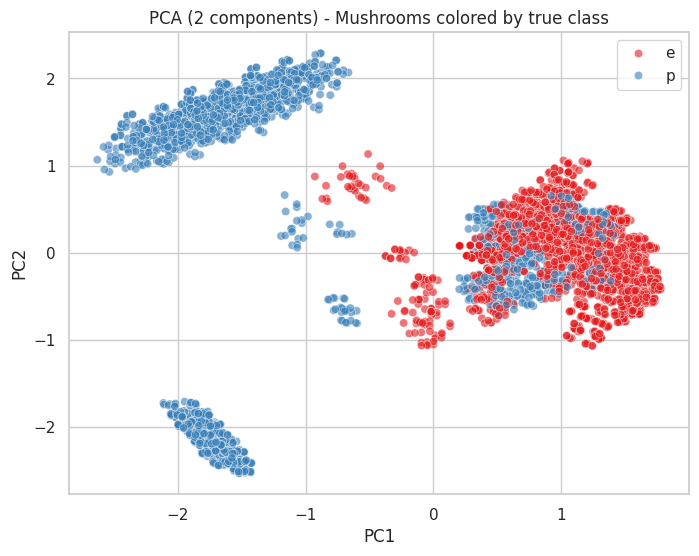

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train.values, palette='Set1', alpha=0.6)
plt.title('PCA (2 components) - Mushrooms colored by true class')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [13]:
clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Random Forest baseline accuracy (all features): {acc:.4f}')


Random Forest baseline accuracy (all features): 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [14]:
X_train.shape


(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

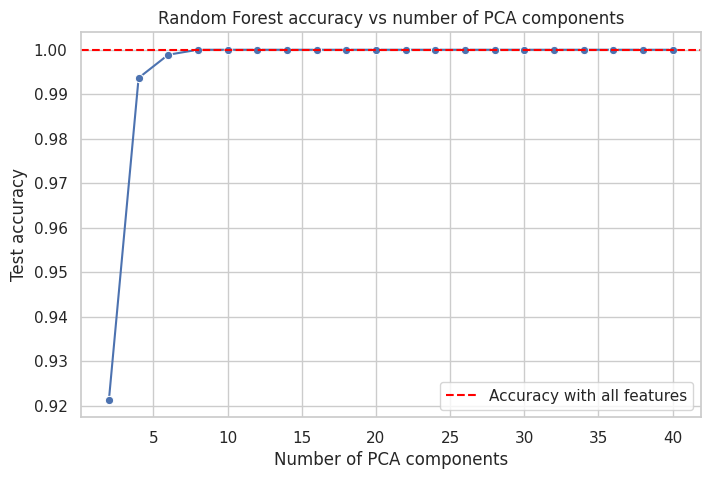

In [15]:
n_features = range(2, 41, 2)  # range of PCA component counts to try
scores = []

for n in n_features:
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_n = pca_n.fit_transform(X_train)
    X_test_n = pca_n.transform(X_test)

    clf_n = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    clf_n.fit(X_train_n, y_train)
    scores.append(accuracy_score(y_test, clf_n.predict(X_test_n)))

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(n_features), y=scores, marker='o')
plt.axhline(acc, color='red', linestyle='--', label='Accuracy with all features')
plt.xlabel('Number of PCA components')
plt.ylabel('Test accuracy')
plt.title('Random Forest accuracy vs number of PCA components')
plt.legend()
plt.show()


A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

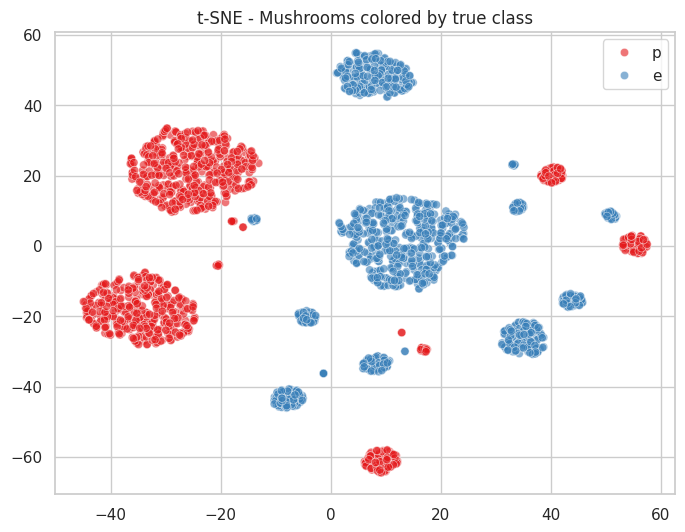

In [16]:
sample_size = 2000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_train.shape[0], size=min(sample_size, X_train.shape[0]), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample.values, palette='Set1', alpha=0.6)
plt.title('t-SNE - Mushrooms colored by true class')
plt.show()


---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [17]:
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_red = pca_10.fit_transform(X)
y_bin = (y == 'p').astype(int).values  # 1 = poisonous, 0 = edible

print('Cumulative explained variance (10 components):', round(pca_10.explained_variance_ratio_.sum(), 4))
print('X_red shape:', X_red.shape)


Cumulative explained variance (10 components): 0.6452
X_red shape: (8124, 10)


### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

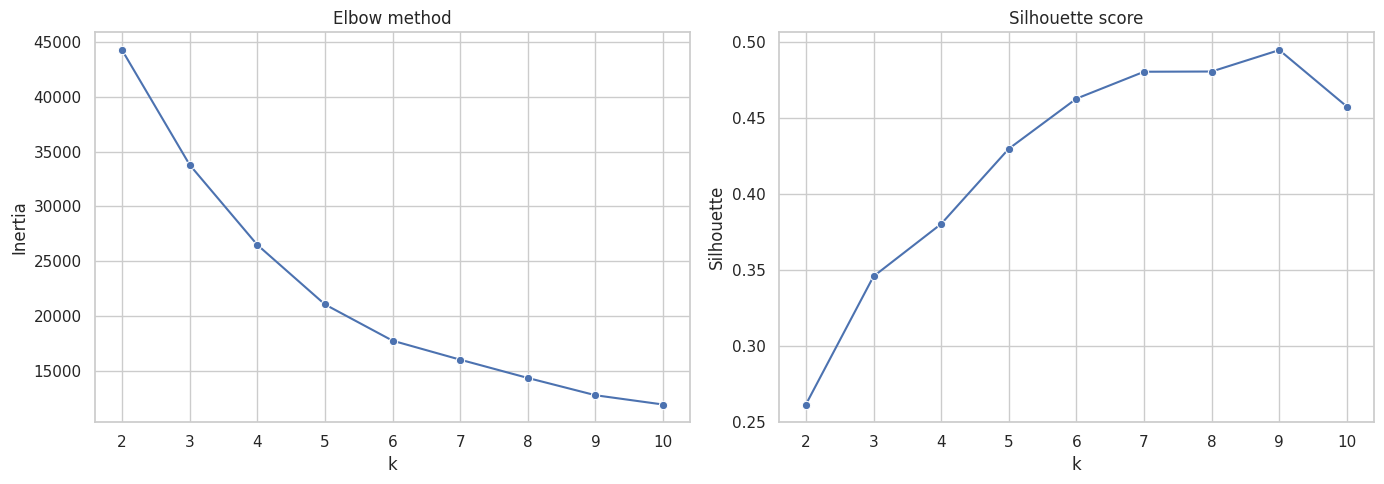

In [18]:
k_values = range(2, 11)
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_red)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x=list(k_values), y=inertias, marker='o', ax=axes[0])
axes[0].set_title('Elbow method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

sns.lineplot(x=list(k_values), y=silhouettes, marker='o', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()


### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

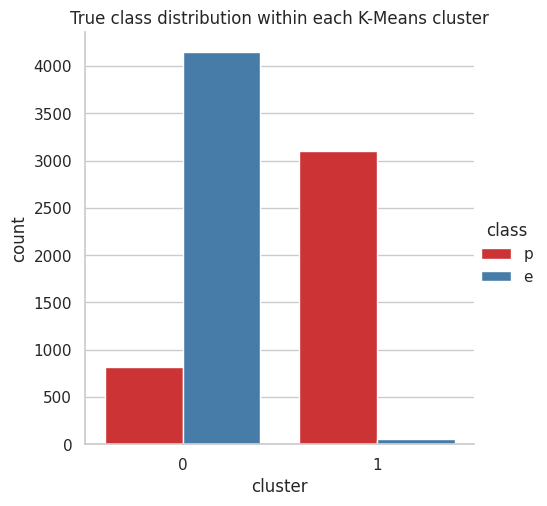

ARI: 0.6171
NMI: 0.5663


In [19]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_red)

df_plot = pd.DataFrame({'cluster': cluster_labels, 'class': y.values})
sns.catplot(x='cluster', hue='class', data=df_plot, kind='count', palette='Set1')
plt.title('True class distribution within each K-Means cluster')
plt.show()

ari = adjusted_rand_score(y_bin, cluster_labels)
nmi = normalized_mutual_info_score(y_bin, cluster_labels)
print(f'ARI: {ari:.4f}')
print(f'NMI: {nmi:.4f}')


> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [20]:
def evaluate(name, labels, X, y_true=None):
    labels = np.asarray(labels)
    mask = labels != -1  # exclude noise points (relevant for DBSCAN)
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        sil, db, ch = np.nan, np.nan, np.nan
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db = davies_bouldin_score(X[mask], labels[mask])
        ch = calinski_harabasz_score(X[mask], labels[mask])
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
    return {'Algorithm': name, 'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch, 'ARI': ari}

results = []

km_r = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_red)
results.append(evaluate('K-Means', km_r.labels_, X_red, y_bin))

agg = AgglomerativeClustering(n_clusters=2).fit(X_red)
results.append(evaluate('Agglomerative', agg.labels_, X_red, y_bin))

gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit(X_red)
gmm_labels = gmm.predict(X_red)
results.append(evaluate('GMM', gmm_labels, X_red, y_bin))

dbscan = DBSCAN(eps=3, min_samples=10).fit(X_red)
results.append(evaluate('DBSCAN', dbscan.labels_, X_red, y_bin))

df_results = pd.DataFrame(results)
df_results


,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,K-Means,0.261416,1.692939,2564.691274,0.617056
1,Agglomerative,0.258872,1.696264,2503.624971,0.608952
2,GMM,0.257873,1.700914,2500.017463,0.598621
3,DBSCAN,NaN,NaN,NaN,0.000000


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

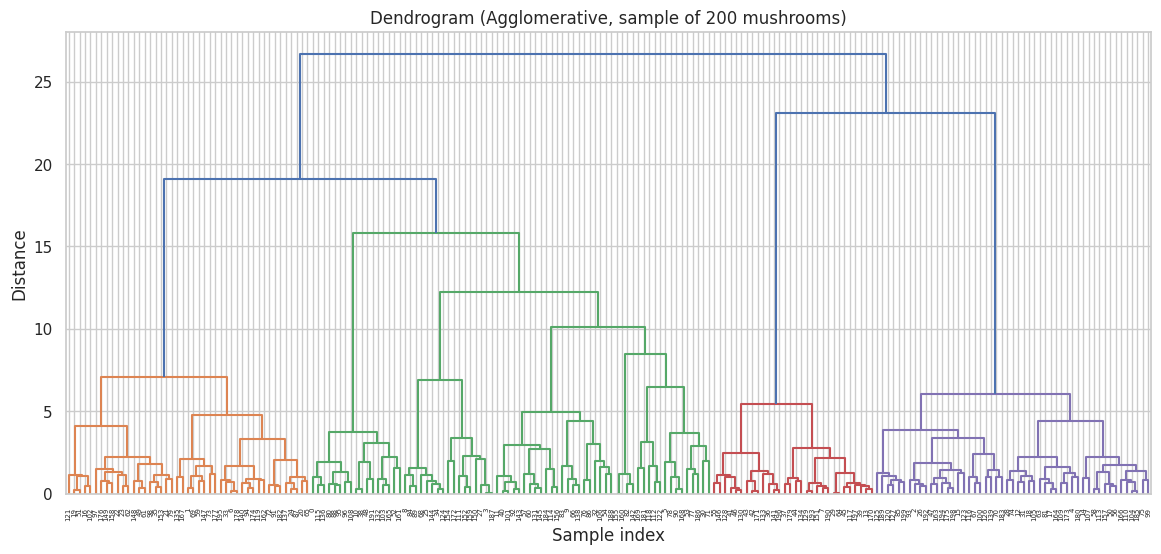

In [21]:
sample_idx2 = rng.choice(X_red.shape[0], size=200, replace=False)
X_dendro = X_red[sample_idx2]

Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z)
plt.title('Dendrogram (Agglomerative, sample of 200 mushrooms)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [22]:
# Euclidean distance on X_red (PCA, 10 components)
dbscan_euc = DBSCAN(eps=3, min_samples=10, metric='euclidean').fit(X_red)
ari_euc = adjusted_rand_score(y_bin, dbscan_euc.labels_)
n_clusters_euc = len(set(dbscan_euc.labels_)) - (1 if -1 in dbscan_euc.labels_ else 0)
print(f'DBSCAN euclidean (PCA): {n_clusters_euc} clusters, noise={ (dbscan_euc.labels_ == -1).sum() }, ARI={ari_euc:.4f}')

# Jaccard distance on the binary one-hot data (sample, due to pairwise distance cost)
sample_idx3 = rng.choice(X.shape[0], size=1500, replace=False)
X_sample_bin = X.iloc[sample_idx3].values
y_sample_bin = y_bin[sample_idx3]

dist_jaccard = pdist(X_sample_bin, metric='jaccard')
dist_matrix = squareform(dist_jaccard)

dbscan_jac = DBSCAN(eps=0.3, min_samples=10, metric='precomputed').fit(dist_matrix)
ari_jac = adjusted_rand_score(y_sample_bin, dbscan_jac.labels_)
n_clusters_jac = len(set(dbscan_jac.labels_)) - (1 if -1 in dbscan_jac.labels_ else 0)
print(f'DBSCAN Jaccard (one-hot, sample of 1500): {n_clusters_jac} clusters, noise={ (dbscan_jac.labels_ == -1).sum() }, ARI={ari_jac:.4f}')


DBSCAN euclidean (PCA): 1 clusters, noise=0, ARI=0.0000


DBSCAN Jaccard (one-hot, sample of 1500): 13 clusters, noise=28, ARI=0.2861


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

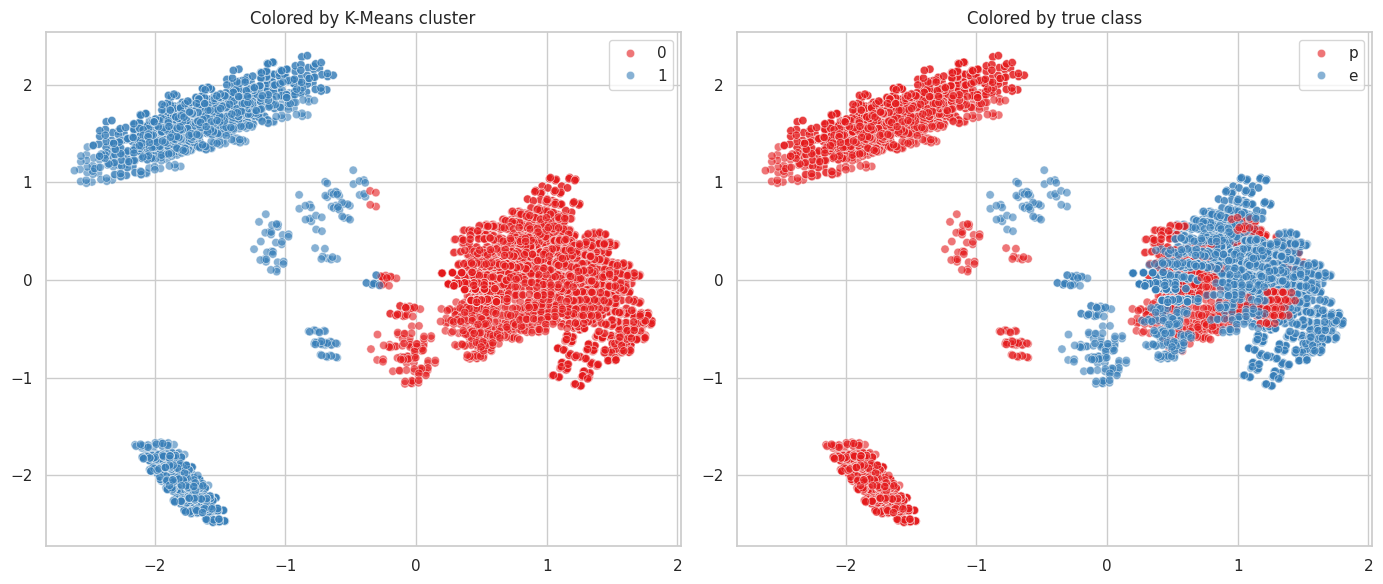

In [23]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=cluster_labels, palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Colored by K-Means cluster')

sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y.values, palette='Set1', alpha=0.6, ax=axes[1])
axes[1].set_title('Colored by true class')

plt.tight_layout()
plt.show()


Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

Anomalies detected: 407 out of 8124 (5.01%)


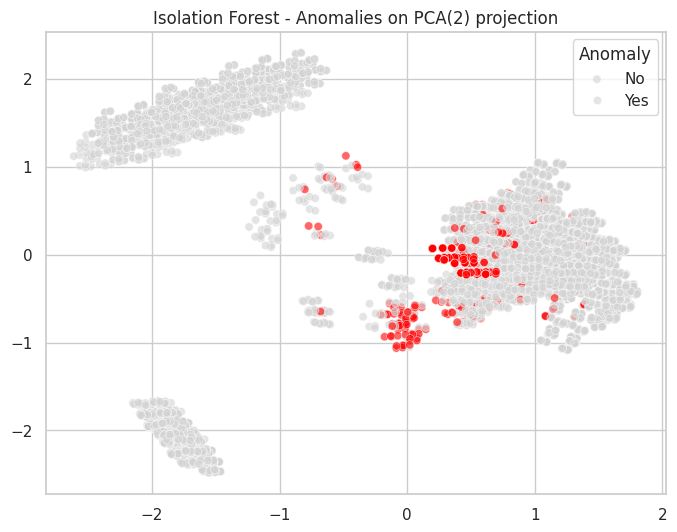

In [24]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso.fit(X_red)
anomaly_labels = iso.predict(X_red)  # -1 = anomaly, 1 = normal

print(f'Anomalies detected: {(anomaly_labels == -1).sum()} out of {len(anomaly_labels)} ({(anomaly_labels == -1).mean() * 100:.2f}%)')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca2[:, 0], y=X_pca2[:, 1],
    hue=(anomaly_labels == -1), palette={True: 'red', False: 'lightgray'}, alpha=0.6
)
plt.title('Isolation Forest - Anomalies on PCA(2) projection')
plt.legend(title='Anomaly', labels=['No', 'Yes'])
plt.show()


---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.